<class 'pandas.DataFrame'>
RangeIndex: 2007 entries, 0 to 2006
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   PetID               2007 non-null   int64  
 1   PetType             2007 non-null   str    
 2   Breed               2007 non-null   str    
 3   AgeMonths           2007 non-null   int64  
 4   Color               2007 non-null   str    
 5   Size                2007 non-null   str    
 6   WeightKg            2007 non-null   float64
 7   Vaccinated          2007 non-null   int64  
 8   HealthCondition     2007 non-null   int64  
 9   TimeInShelterDays   2007 non-null   int64  
 10  AdoptionFee         2007 non-null   int64  
 11  PreviousOwner       2007 non-null   int64  
 12  AdoptionLikelihood  2007 non-null   int64  
dtypes: float64(1), int64(8), str(4)
memory usage: 204.0 KB


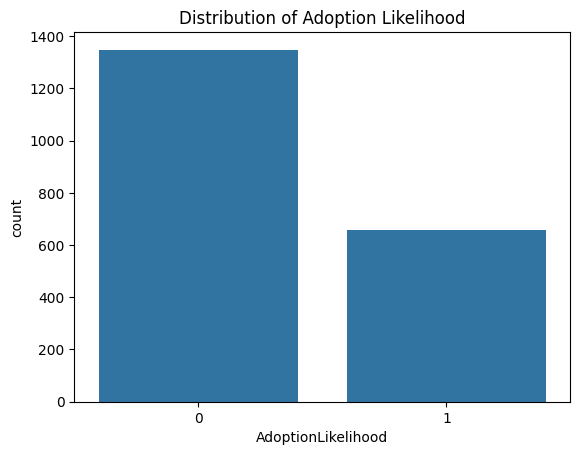

In [41]:
%run EDA.ipynb
zmienne_kategoryczne = ['PetType', 'Breed', 'Color', 'Size']
X_train = pd.get_dummies(X_train, columns=zmienne_kategoryczne, drop_first=True)
X_test = pd.get_dummies(X_test, columns=zmienne_kategoryczne, drop_first=True)

X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)


In [42]:
from sklearn.metrics import make_scorer

def moja_metryka(y_true, y_proba, **kwargs):
    return symulacja_budzetu(y_true, y_proba)

scorer = make_scorer(moja_metryka, needs_proba=True)

In [43]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.metrics import precision_score, recall_score, classification_report, ConfusionMatrixDisplay

clf = DecisionTreeClassifier(random_state=42)
clf.fit(X_train, y_train)


,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [54]:
param_grid = {
    'max_depth': [2, 3, 5, 8, 10, None],
    'min_samples_leaf': [1, 5, 10, 20],
    'class_weight': [None, 'balanced']
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    param_grid,
    cv=cv,
    scoring=scorer,
    n_jobs=-1
)

grid.fit(X_train, y_train)
y_pred = grid.best_estimator_.predict(X_test)
print(grid.best_params_)
print(grid.best_score_)

{'class_weight': None, 'max_depth': 5, 'min_samples_leaf': 5}
13.4


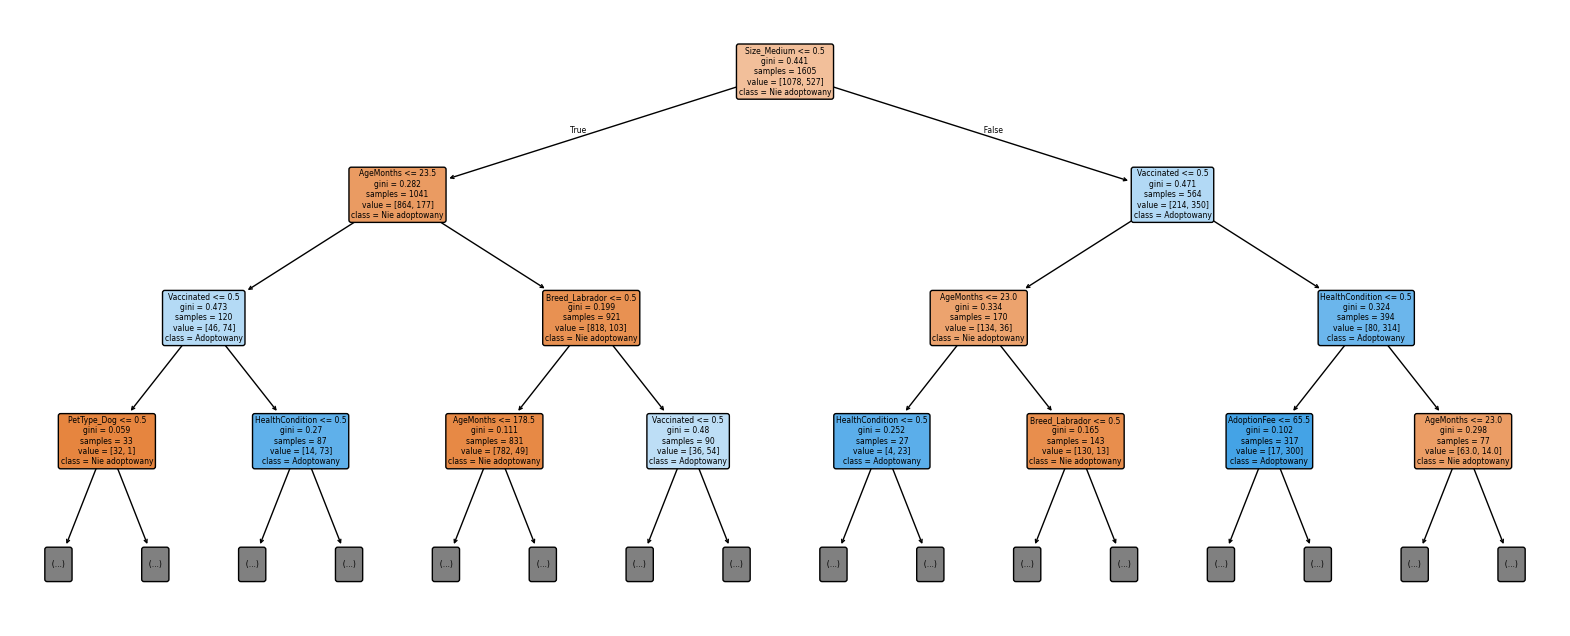

In [56]:
plt.figure(figsize=(20, 8))
plot_tree(
    grid.best_estimator_,  
    max_depth=3,   
    filled=True,         
    feature_names=X_train.columns.tolist(),
    class_names=['Nie adoptowany', 'Adoptowany'],
    rounded=True
)
plt.show()

In [52]:
symulacja_budzetu(y_test, grid.best_estimator_.predict_proba(X_test)[:, 1])

np.float64(12.799999999999999)

In [47]:
rate = y_test.mean()
baseline = 20 * (rate * 0.7 + (1 - rate) * 0.1)
print(baseline)

5.940298507462687


In [55]:
y_proba_base = clf.predict_proba(X_test)[:, 1]
y_proba_tuned = grid.best_estimator_.predict_proba(X_test)[:, 1]

print('Bazowe drzewo:', symulacja_budzetu(y_test, y_proba_base))
print('Po tuningu:', symulacja_budzetu(y_test, y_proba_tuned))
print('Baseline losowy:', baseline)

Bazowe drzewo: 11.6
Po tuningu: 12.799999999999999
Baseline losowy: 5.940298507462687


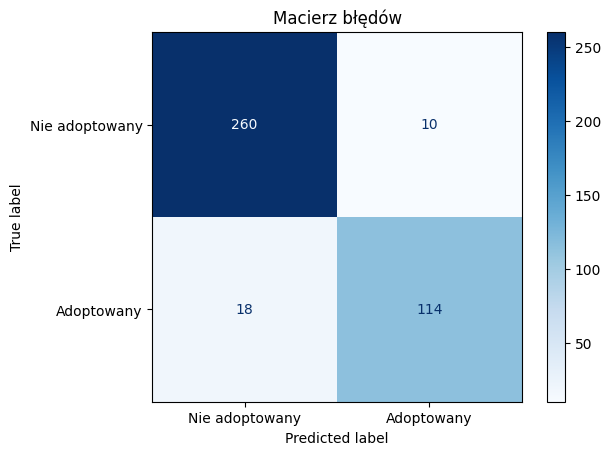

In [58]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    grid.best_estimator_.predict(X_test),
    display_labels=['Nie adoptowany', 'Adoptowany'],
    cmap='Blues'
)
plt.title('Macierz błędów')
plt.show()

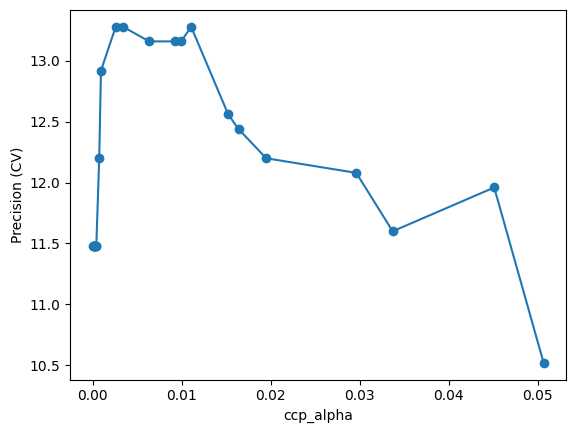

In [48]:
path = grid.best_estimator_.cost_complexity_pruning_path(X_train, y_train)
alphas = path.ccp_alphas[:-1]  # ostatnia to korzeń, pomijamy
scores = []
for alpha in alphas[::max(1, len(alphas)//20)]:  # co kilkanaście żeby nie było ich za dużo
    clf_pruned = DecisionTreeClassifier(ccp_alpha=alpha, random_state=42)
    score = cross_val_score(clf_pruned, X_train, y_train, cv=cv, scoring=scorer).mean()
    scores.append((alpha, score))

a, s = zip(*scores)
plt.plot(a, s, marker='o')
plt.xlabel('ccp_alpha')
plt.ylabel('Precision (CV)')
plt.show()

In [53]:
import numpy as np
best_alpha = a[np.argmax(s)]
clf_pruned = DecisionTreeClassifier(ccp_alpha=best_alpha, random_state=42)
clf_pruned.fit(X_train, y_train)
y_pred_pruned = clf_pruned.predict(X_test)
print(symulacja_budzetu(y_test, clf_pruned.predict_proba(X_test)[:, 1]))

12.799999999999999


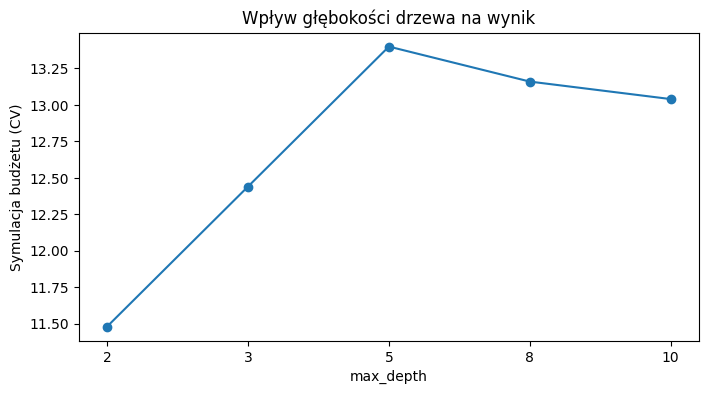

In [57]:
results = pd.DataFrame(grid.cv_results_)
depth_results = results.groupby('param_max_depth')['mean_test_score'].max().reset_index()
depth_results['param_max_depth'] = depth_results['param_max_depth'].astype(str)

plt.figure(figsize=(8, 4))
plt.plot(depth_results['param_max_depth'], depth_results['mean_test_score'], marker='o')
plt.xlabel('max_depth')
plt.ylabel('Symulacja budżetu (CV)')
plt.title('Wpływ głębokości drzewa na wynik')
plt.show()